# **Cell 1 Imports & Plotting Setup**

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)

# **Cell 2 Dataset**

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

ZIP_PATH = "/content/drive/MyDrive/cleaned_dataset.zip"

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError("cleaned_dataset.zip not found in My Drive.")

print("Dataset found:")
print(ZIP_PATH)

Mounted at /content/drive
Dataset found:
/content/drive/MyDrive/cleaned_dataset.zip


# ***Extract Dataset***

In [ ]:
import zipfile

EXTRACT_DIR = "/content/battery_dataset"

os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset extracted successfully.")

Dataset extracted successfully.


# ***Find Meta Data***

In [ ]:
import glob
import os

metadata_files = glob.glob(
    "/content/battery_dataset/**/metadata.csv",
    recursive=True
)

if not metadata_files:
    raise FileNotFoundError("metadata.csv not found inside the dataset.")

METADATA_PATH = metadata_files[0]

DATA_DIR = os.path.join(
    os.path.dirname(METADATA_PATH),
    "data"
)

print("Metadata:", METADATA_PATH)
print("Data directory:", DATA_DIR)

Metadata: /content/battery_dataset/cleaned_dataset/metadata.csv
Data directory: /content/battery_dataset/cleaned_dataset/data


# **Cell 3 Load & Clean Data**

In [ ]:
df = pd.read_csv(METADATA_PATH)
df["Capacity"] = pd.to_numeric(
    df["Capacity"]
    .astype(str)
    .str.replace(r"[\[\]]", "", regex=True),
    errors="coerce"
)
discharge = (
    df[
        (df["type"] == "discharge") &
        (df["Capacity"] > 0.05)
    ]
    .sort_values(["battery_id", "test_id"])
    .copy()
)
print("Total discharge records:", len(discharge))
print("Total batteries:", discharge["battery_id"].nunique())

Total discharge records: 2714
Total batteries: 34


# **Cell 4 Calculate Initial Capacity & SOH**

In [ ]:
initial_capacity = (
    discharge
    .groupby("battery_id")["Capacity"]
    .first()
)

discharge["Initial_Capacity"] = (
    discharge["battery_id"]
    .map(initial_capacity)
)

discharge["SOH"] = (
    discharge["Capacity"] /
    discharge["Initial_Capacity"] * 100
)

discharge[["battery_id", "test_id", "Capacity", "SOH"]].head()

,battery_id,test_id,Capacity,SOH
5121,B0005,1,1.856487,100.000000
5123,B0005,3,1.846327,99.452721
5125,B0005,5,1.835349,98.861386
5127,B0005,7,1.835263,98.856718
5129,B0005,9,1.834646,98.823482


# **Cell 5 Calculate RUL**

In [ ]:
def calculate_rul(group):

    eol_threshold = 0.70 * group["Initial_Capacity"].iloc[0]

    eol_cycles = group.loc[
        group["Capacity"] <= eol_threshold,
        "test_id"
    ]

    eol_cycle = (
        eol_cycles.iloc[0]
        if not eol_cycles.empty
        else group["test_id"].max()
    )

    group["EOL_Cycle"] = eol_cycle

    group["RUL"] = np.maximum(
        0,
        eol_cycle - group["test_id"]
    )

    return group


discharge = (
    discharge
    .groupby("battery_id", group_keys=False)
    .apply(calculate_rul)
)

discharge[["battery_id", "test_id", "SOH", "RUL"]].head()

/tmp/ipykernel_7864/914899265.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_rul)


,battery_id,test_id,SOH,RUL
5121,B0005,1,100.000000,590
5123,B0005,3,99.452721,588
5125,B0005,5,98.861386,586
5127,B0005,7,98.856718,584
5129,B0005,9,98.823482,582


# **Cell 6 Capacity Degradation Plot**

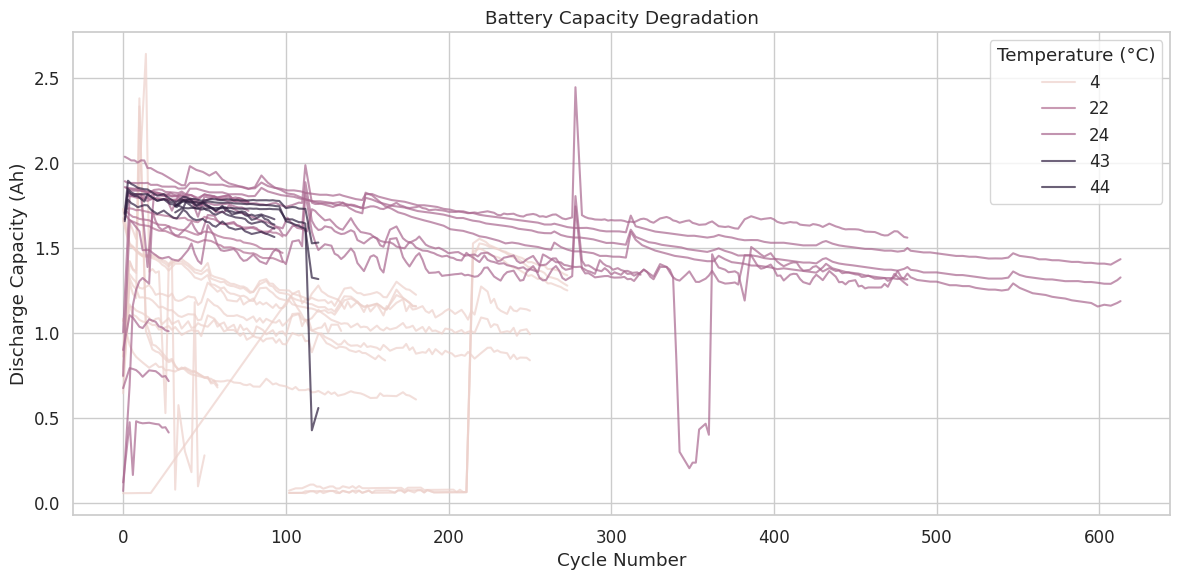

In [ ]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=discharge,
    x="test_id",
    y="Capacity",
    hue="ambient_temperature",
    units="battery_id",
    estimator=None,
    alpha=0.7
)

plt.title("Battery Capacity Degradation")
plt.xlabel("Cycle Number")
plt.ylabel("Discharge Capacity (Ah)")
plt.legend(title="Temperature (°C)")

plt.tight_layout()
plt.show()

# **Cell 7 SOH Degradation Plot**

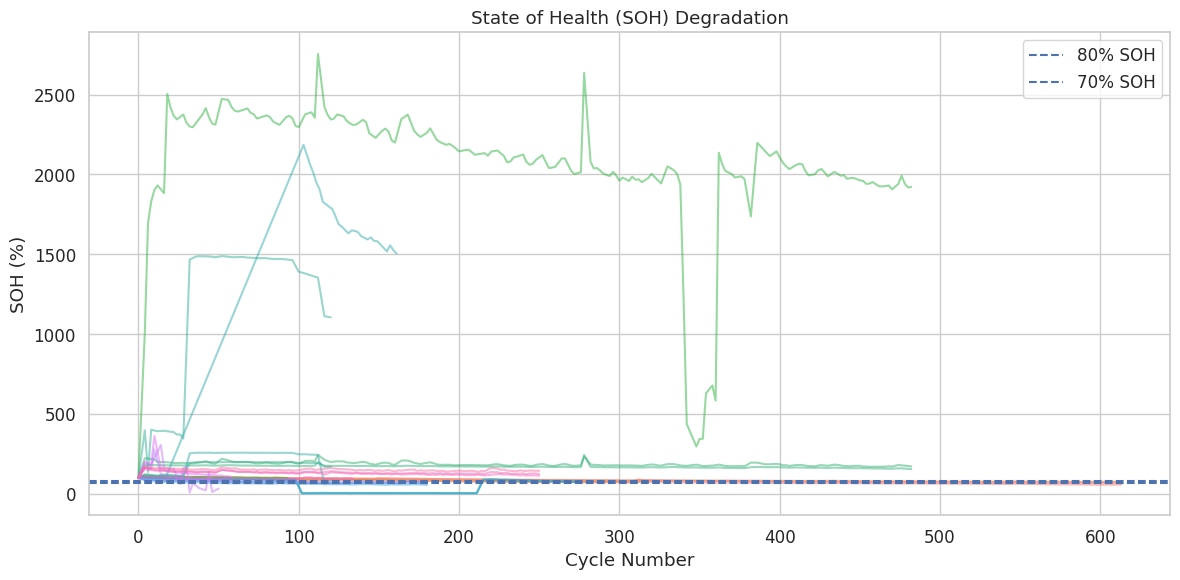

In [ ]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=discharge,
    x="test_id",
    y="SOH",
    hue="battery_id",
    legend=False,
    alpha=0.5
)

plt.axhline(
    80,
    linestyle="--",
    label="80% SOH"
)

plt.axhline(
    70,
    linestyle="--",
    label="70% SOH"
)

plt.title("State of Health (SOH) Degradation")
plt.xlabel("Cycle Number")
plt.ylabel("SOH (%)")
plt.legend()

plt.tight_layout()
plt.show()

# **Cell 8 RUL Distribution**

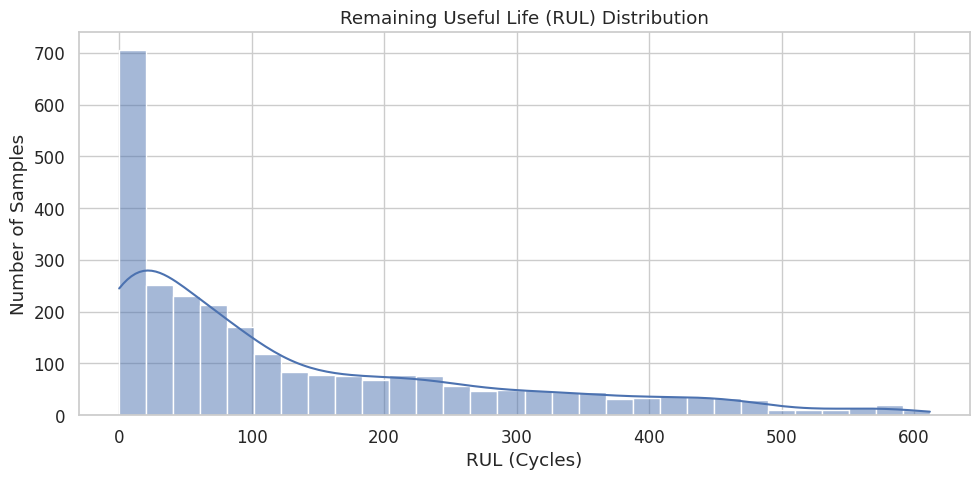

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    discharge["RUL"],
    bins=30,
    kde=True
)

plt.title("Remaining Useful Life (RUL) Distribution")
plt.xlabel("RUL (Cycles)")
plt.ylabel("Number of Samples")

plt.tight_layout()
plt.show()

# **Cell 9 Battery Quality Audit**

In [ ]:
discharge["Capacity_Change"] = (
    discharge
    .groupby("battery_id")["Capacity"]
    .diff()
    .abs()
)

audit = (
    discharge
    .groupby("battery_id")
    .agg(
        Total_Cycles=("test_id", "count"),
        Min_Capacity=("Capacity", "min"),
        Max_Capacity=("Capacity", "max"),
        Mean_Capacity_Change=("Capacity_Change", "mean")
    )
    .reset_index()
)

display(audit)

,battery_id,Total_Cycles,Min_Capacity,Max_Capacity,Mean_Capacity_Change
0,B0005,168,1.287453,1.856487,0.008143
1,B0006,168,1.153818,2.035338,0.014357
2,B0007,168,1.400455,1.891052,0.006941
3,B0018,132,1.341051,1.855005,0.014155
4,B0025,28,1.767789,1.848984,0.008611
5,B0026,28,1.386337,1.816528,0.051927
6,B0027,28,1.770093,1.823308,0.009538
7,B0028,28,1.717234,1.804783,0.007148
8,B0029,40,1.612080,1.844701,0.014417
9,B0030,40,1.562780,1.781555,0.016079


# **Cell 10 Identify Difficult and Anomalous Batteries**

In [ ]:
difficult_cells = audit[
    (audit["Mean_Capacity_Change"] > 0.04) |
    (audit["Total_Cycles"] < 30)
]

print("Potentially Difficult / Anomalous Batteries:")

display(difficult_cells)

Potentially Difficult / Anomalous Batteries:


,battery_id,Total_Cycles,Min_Capacity,Max_Capacity,Mean_Capacity_Change
4,B0025,28,1.767789,1.848984,0.008611
5,B0026,28,1.386337,1.816528,0.051927
6,B0027,28,1.770093,1.823308,0.009538
7,B0028,28,1.717234,1.804783,0.007148
12,B0033,197,0.068426,1.885140,0.045672
16,B0039,47,0.119038,1.771573,0.062922
17,B0040,47,0.425812,1.734130,0.060189
18,B0041,32,0.055620,1.215649,0.052150
26,B0049,24,0.691389,2.378644,0.147238
27,B0050,19,0.076584,2.640149,0.530039


# **Cell 11 Final Summary**

In [ ]:
print("Dataset Summary")

print(
    f"Total batteries       : "
    f"{discharge['battery_id'].nunique()}"
)

print(
    f"Total discharge cycles: "
    f"{len(discharge)}"
)

print(
    f"Average initial capacity: "
    f"{discharge['Initial_Capacity'].mean():.3f} Ah"
)

print(
    f"Average SOH           : "
    f"{discharge['SOH'].mean():.2f}%"
)

print(
    f"Average RUL           : "
    f"{discharge['RUL'].mean():.1f} cycles"
)

Dataset Summary
Total batteries       : 34
Total discharge cycles: 2714
Average initial capacity: 1.280 Ah
Average SOH           : 282.48%
Average RUL           : 134.5 cycles
